# FIFA World Cup Winner Prediction: XGBoost Models

This notebook starts from exactly two datasets:

1. `matches_preprocessed_readable.csv`: international matches with Elo ratings and an `is_world_cup` flag.
2. `matches.csv`: authoritative FIFA World Cup match data, including stage and knockout winners.

## Modeling tasks

- **All World Cup matches:** three outcomes — first-listed team wins, draw, or second-listed team wins.
- **Knockout matches:** binary winner — one of the two participating teams must advance.

The final output converts the internal relative class into the **actual team name**.


In [12]:
import sys
!{sys.executable} -m pip install xgboost

In [13]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 150)

In [14]:
#Read files
PROCESSED_PATH = "../data/processed/matches_preprocessed_readable.csv"
WORLD_CUP_PATH = "../data/matches.csv"

processed_international_matches = pd.read_csv(PROCESSED_PATH)
world_cup_matches = pd.read_csv(WORLD_CUP_PATH)

print("Processed dataset shape:", processed_international_matches.shape)
print("World Cup matches shape:", world_cup_matches.shape)

Processed dataset shape: (29904, 20)
World Cup matches shape: (1248, 37)


In [15]:
display(processed_international_matches.head())
display(world_cup_matches.head())

,date,year,home_team,away_team,home_team_clean,away_team_clean,home_score,away_score,match_result,tournament,city,country,neutral,is_world_cup,home_elo,away_elo,elo_diff,goal_diff,abs_goal_diff,total_goals
0,1994-01-02,1994,Barbados,Grenada,Barbados,Grenada,0,0,draw,Friendly,Bridgetown,Barbados,False,False,1248.0,1363.0,-115.0,0,0,0
1,1994-01-02,1994,Ghana,Egypt,Ghana,Egypt,2,1,home_win,Friendly,Accra,Ghana,False,False,1622.0,1663.0,-41.0,1,1,3
2,1994-01-05,1994,Mali,Burkina Faso,Mali,Burkina Faso,1,1,draw,Friendly,Bamako,Mali,False,False,1501.0,1324.0,177.0,0,0,2
3,1994-01-09,1994,Mauritania,Mali,Mauritania,Mali,1,3,away_win,Friendly,Nouakchott,Mauritania,False,False,1077.0,1501.0,-424.0,-2,2,4
4,1994-01-11,1994,Thailand,Nigeria,Thailand,Nigeria,1,1,draw,Friendly,Bangkok,Thailand,False,False,1354.0,1622.0,-268.0,0,0,2


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,replay,match_date,match_time,stadium_id,stadium_name,city_name,country_name,home_team_id,home_team_name,home_team_code,away_team_id,away_team_name,away_team_code,score,home_team_score,away_team_score,home_team_score_margin,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,0,1930-07-13,15:00,S-240,Estadio Pocitos,Montevideo,Uruguay,T-30,France,FRA,T-46,Mexico,MEX,4–1,4,1,3,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,0,1930-07-13,15:00,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-83,United States,USA,T-06,Belgium,BEL,3–0,3,0,3,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,0,1930-07-14,12:45,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-87,Yugoslavia,YUG,T-09,Brazil,BRA,2–1,2,1,1,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,0,1930-07-14,14:50,S-240,Estadio Pocitos,Montevideo,Uruguay,T-61,Romania,ROU,T-56,Peru,PER,3–1,3,1,2,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,0,1930-07-15,16:00,S-239,Estadio Gran Parque Central,Montevideo,Uruguay,T-03,Argentina,ARG,T-30,France,FRA,1–0,1,0,1,-1,0,0,0-0,0,0,home team win,1,0,0


In [16]:
# Confirm the fields created by 02_data_preprocessing are available.
required_processed_columns = [
    "date", "year",
    "home_team_clean", "away_team_clean",
    "home_score", "away_score", "match_result",
    "tournament", "country", "neutral", "is_world_cup",
    "home_elo", "away_elo", "elo_diff",
]

required_world_cup_columns = [
    "tournament_name", "match_id", "match_date",
    "stage_name", "group_name", "group_stage", "knockout_stage",
    "country_name", "home_team_name", "away_team_name",
    "home_team_score", "away_team_score",
    "extra_time", "penalty_shootout",
    "home_team_win", "away_team_win", "draw",
]

missing_processed = sorted(
    set(required_processed_columns) - set(processed_international_matches.columns)
)
missing_world_cup = sorted(
    set(required_world_cup_columns) - set(world_cup_matches.columns)
)

assert not missing_processed, f"Missing processed columns: {missing_processed}"
assert not missing_world_cup, f"Missing World Cup columns: {missing_world_cup}"

print("Required preprocessed and World Cup fields are available.")

Required preprocessed and World Cup fields are available.


## Feature Engineering

From notebook 02_data_preprocessing which includes feature engineering we already have the following:
- team-name cleaning in the processed international-match dataset;
- the pregame Elo merge;
- removal of unusable rows;
- creation of `home_elo`, `away_elo`, and `elo_diff`.

The following in this notebook adds new pre-match features, World Cup context, and the two prediction models.

In [17]:
processed_international_matches["date"] = pd.to_datetime(processed_international_matches["date"])
world_cup_matches["match_date"] = pd.to_datetime(world_cup_matches["match_date"])

processed_international_matches = processed_international_matches.sort_values("date").reset_index(drop=True)
processed_international_matches["match_idx"] = np.arange(len(processed_international_matches))

# Internal relative target:
# 0 = first-listed team wins, 1 = second-listed team wins, 2 = draw
processed_international_matches["target"] = processed_international_matches["match_result"].map({
    "home_win": 0,
    "away_win": 1,
    "draw": 2,
}).astype(int)

# is_world_cup also includes qualification matches, get only fifa world cup matches
processed_international_matches["actual_fifa_world_cup"] = (
    processed_international_matches["tournament"].eq("FIFA World Cup").astype(int)
)

# The home_elo and away_elo are taken from elo prior to the match date
# Calculate the expected elo of the team in respect to their opponent for this match to help with the prediction
processed_international_matches["home_elo_expected"] = (1 / (1 + 10 ** (-processed_international_matches["elo_diff"] / 400)))
processed_international_matches["away_elo_expected"] = 1 - processed_international_matches["home_elo_expected"]

print("Rows flagged by is_world_cup:", int(processed_international_matches["is_world_cup"].sum()))
print("Actual FIFA World Cup finals rows:",int(processed_international_matches["actual_fifa_world_cup"].sum()))

Rows flagged by is_world_cup: 7045
Actual FIFA World Cup finals rows: 502


In [18]:
display(processed_international_matches.head())

,date,year,home_team,away_team,home_team_clean,away_team_clean,home_score,away_score,match_result,tournament,city,country,neutral,is_world_cup,home_elo,away_elo,elo_diff,goal_diff,abs_goal_diff,total_goals,match_idx,target,actual_fifa_world_cup,home_elo_expected,away_elo_expected
0,1994-01-02,1994,Barbados,Grenada,Barbados,Grenada,0,0,draw,Friendly,Bridgetown,Barbados,False,False,1248.0,1363.0,-115.0,0,0,0,0,2,0,0.340292,0.659708
1,1994-01-02,1994,Ghana,Egypt,Ghana,Egypt,2,1,home_win,Friendly,Accra,Ghana,False,False,1622.0,1663.0,-41.0,1,1,3,1,0,0,0.441269,0.558731
2,1994-01-05,1994,Mali,Burkina Faso,Mali,Burkina Faso,1,1,draw,Friendly,Bamako,Mali,False,False,1501.0,1324.0,177.0,0,0,2,2,2,0,0.734757,0.265243
3,1994-01-09,1994,Mauritania,Mali,Mauritania,Mali,1,3,away_win,Friendly,Nouakchott,Mauritania,False,False,1077.0,1501.0,-424.0,-2,2,4,3,1,0,0.080118,0.919882
4,1994-01-11,1994,Thailand,Nigeria,Thailand,Nigeria,1,1,draw,Friendly,Bangkok,Thailand,False,False,1354.0,1622.0,-268.0,0,0,2,4,2,0,0.176138,0.823862


### Add recent history features for each team
For each team, each game we'll add 2 measures over the previous 5 matches:
* average points earned
* average goal difference

In [19]:
# Create one row per team per match so we can calculate each team's form before the current match
# For the "points", if the team wins -> 3pts , draw -> 1pt, opponent wins -> 0pt
first_team_history = pd.DataFrame({
    "match_idx": processed_international_matches["match_idx"],
    "date": processed_international_matches["date"],
    "team": processed_international_matches["home_team_clean"],
    "team_position": "first",
    "points": np.select([
            processed_international_matches["match_result"].eq("home_win"),
            processed_international_matches["match_result"].eq("draw")],
                        [3, 1], default=0),
    "goal_difference": (processed_international_matches["home_score"] - processed_international_matches["away_score"])})

second_team_history = pd.DataFrame({
    "match_idx": processed_international_matches["match_idx"],
    "date": processed_international_matches["date"],
    "team": processed_international_matches["away_team_clean"],
    "team_position": "second",
    "points": np.select([
            processed_international_matches["match_result"].eq("away_win"),
            processed_international_matches["match_result"].eq("draw")],
        [3, 1], default=0),
    "goal_difference": (processed_international_matches["away_score"] - processed_international_matches["home_score"])})

team_history = pd.concat([first_team_history, second_team_history], ignore_index=True,)
team_history = team_history.sort_values(["team", "date", "match_idx"]).reset_index(drop=True)
team_group = team_history.groupby("team", group_keys=False)

# Use shift(1) to get only the matches occurring before the current match to get the average points and average goal from last 5 games
team_history["points_last_5"] = (team_group["points"]
    .transform(lambda values: (values.shift(1).rolling(window=5, min_periods=1).mean())))

team_history["goal_difference_last_5"] = (team_group["goal_difference"]
    .transform(lambda values: (values.shift(1).rolling(window=5, min_periods=1).mean())))

display(team_history.head(10))

,match_idx,date,team,team_position,points,goal_difference,points_last_5,goal_difference_last_5
0,16757,2012-09-25,Abkhazia,first,1,0,NaN,NaN
1,16901,2012-10-21,Abkhazia,second,0,-3,1.000000,0.0
2,17814,2013-09-23,Abkhazia,first,3,3,0.500000,-1.5
3,18277,2014-06-01,Abkhazia,first,1,0,1.333333,0.0
4,18291,2014-06-02,Abkhazia,second,3,1,1.250000,0.0
5,18308,2014-06-04,Abkhazia,first,1,0,1.600000,0.2
6,18323,2014-06-05,Abkhazia,second,1,0,1.600000,0.2
7,18341,2014-06-07,Abkhazia,first,0,-1,1.800000,0.8
8,19139,2015-05-05,Abkhazia,first,3,1,1.200000,0.0
9,19144,2015-05-14,Abkhazia,first,3,1,1.600000,0.2


In [20]:
# Merge each team's recent averages into each match
# Select the rolling features for the first-listed team
first_team_features = (team_history.loc[team_history["team_position"]
    .eq("first"),["match_idx", "points_last_5", "goal_difference_last_5",]]
    .rename(columns={"points_last_5": "first_points_last_5", "goal_difference_last_5": "first_goal_difference_last_5"}))

# Select the rolling features for the second-listed team
second_team_features = (team_history.loc[team_history["team_position"]
    .eq("second"),["match_idx", "points_last_5", "goal_difference_last_5"]]
    .rename(columns={"points_last_5": "second_points_last_5", "goal_difference_last_5": "second_goal_difference_last_5"}))

# Merge both teams' features back into one row per match
processed_international_matches = (processed_international_matches
    .merge(first_team_features, on="match_idx", how="left")
    .merge(second_team_features, on="match_idx", how="left")
)

# Compare the two teams directly
processed_international_matches["points_last_5_diff"] = (processed_international_matches["first_points_last_5"] - processed_international_matches["second_points_last_5"])
processed_international_matches["goal_difference_last_5_diff"] = (processed_international_matches["first_goal_difference_last_5"] - processed_international_matches["second_goal_difference_last_5"])

display(processed_international_matches[
        [
            "date",
            "home_team_clean",
            "away_team_clean",
            "first_points_last_5",
            "second_points_last_5",
            "points_last_5_diff",
            "first_goal_difference_last_5",
            "second_goal_difference_last_5",
            "goal_difference_last_5_diff",
        ]
    ].head(10)
)

,date,home_team_clean,away_team_clean,first_points_last_5,second_points_last_5,points_last_5_diff,first_goal_difference_last_5,second_goal_difference_last_5,goal_difference_last_5_diff
0,1994-01-02,Barbados,Grenada,NaN,NaN,NaN,NaN,NaN,NaN
1,1994-01-02,Ghana,Egypt,NaN,NaN,NaN,NaN,NaN,NaN
2,1994-01-05,Mali,Burkina Faso,NaN,NaN,NaN,NaN,NaN,NaN
3,1994-01-09,Mauritania,Mali,NaN,1.0,NaN,NaN,0.0,NaN
4,1994-01-11,Thailand,Nigeria,NaN,NaN,NaN,NaN,NaN,NaN
5,1994-01-15,United States,Norway,NaN,NaN,NaN,NaN,NaN,NaN
6,1994-01-18,Guinea,Ivory Coast,NaN,NaN,NaN,NaN,NaN,NaN
7,1994-01-19,Costa Rica,Norway,NaN,0.0,NaN,NaN,-1.0,NaN
8,1994-01-19,Mexico,Bulgaria,NaN,NaN,NaN,NaN,NaN,NaN
9,1994-01-19,Spain,Portugal,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
# The first games will not have any value for the rolling averages because we do shift(1) like shown above
# but just to be sure we need to see if the number of NaNs is reasonable 
new_stats_cols = [
    "first_points_last_5",
    "second_points_last_5",
    "first_goal_difference_last_5",
    "second_goal_difference_last_5",
]
processed_international_matches[new_stats_cols].isna().mean()

first_points_last_5              0.005250
second_points_last_5             0.005551
first_goal_difference_last_5     0.005250
second_goal_difference_last_5    0.005551
dtype: float64

### Merge world cup stage informatin to the world cup matches
We will match the processed dataset to world cup matches using:
* Match date
* The two participating teams, regardless of which one is listed first

The important reason for matching the two datasets is not mainly to add many stage features. It is to:
* Separate actual World Cup tournament matches from qualifiers.
* Identify whether a match is group stage or knockout.
* Get the team that advanced when a knockout match went to extra time or penalties.

In [22]:
# Some World Cup team names do not match the cleaned names in the international dataset,
# so apply aliases only when creating the matching key.
# Note: Serbia inherited the recognized football-association history from Yugoslavia.
world_cup_match_aliases = {
    "Republic of Ireland": "Ireland",
    "Serbia and Montenegro": "Serbia",
    "Serbia Montenegro": "Serbia",
    "Czech Republic": "Czechia",
    "Yugoslavia": "Serbia",
}

# Prepare dates for matching
processed_international_matches["date"] = pd.to_datetime(processed_international_matches["date"])
world_cup_matches["match_date"] = pd.to_datetime(world_cup_matches["match_date"])

# Keep men's World Cup matches that overlap with the processed dataset
mens_world_cup = world_cup_matches.loc[world_cup_matches["tournament_name"].str.contains("Men's", na=False)
    & world_cup_matches["match_date"].ge(processed_international_matches["date"].min())].copy()

# Create an order-independent team-pair key for the processed dataset
processed_international_matches["team_pair_key"] = (processed_international_matches.apply(
        lambda row: " | ".join(sorted([row["home_team_clean"], row["away_team_clean"],])), axis=1))

# Create an order-independent team-pair key for the World Cup dataset.
# Apply aliases only inside this key, do not replace the original names.
mens_world_cup["team_pair_key"] = mens_world_cup.apply(
    lambda row: " | ".join(sorted([world_cup_match_aliases.get(row["home_team_name"], row["home_team_name"]),
                                   world_cup_match_aliases.get(row["away_team_name"], row["away_team_name"])])), axis=1)

# Check how many World Cup matches can be matched
world_cup_match_check = mens_world_cup.merge(processed_international_matches[["date", "team_pair_key"]].drop_duplicates(),
    left_on=["match_date", "team_pair_key"],
    right_on=["date", "team_pair_key"],
    how="left",
    indicator=True,
)

print("World Cup matches available:", len(world_cup_match_check))
print("Directly matched:", world_cup_match_check["_merge"].eq("both").sum())
print("Unmatched:", world_cup_match_check["_merge"].eq("left_only").sum())

display(world_cup_match_check.loc[
        world_cup_match_check["_merge"].eq("left_only"), [
            "match_date",
            "home_team_name",
            "away_team_name",
            "tournament_name"
        ]].head(20))

World Cup matches available: 500
Directly matched: 500
Unmatched: 0


,match_date,home_team_name,away_team_name,tournament_name


In [23]:
# Keep only actual FIFA World Cup tournament matches.
# The rolling features were already calculated using all prior international matches.
processed_world_cup = processed_international_matches.loc[processed_international_matches["tournament"].eq("FIFA World Cup")].copy()

# Confirm the World Cup matching keys are unique before merging
print("Duplicate processed World Cup keys:", processed_world_cup.duplicated(subset=["date", "team_pair_key"], keep=False).sum())

# Merge the World Cup metadata with the pre-match features
world_cup_model_data = processed_world_cup.merge(
    mens_world_cup[
        [
            "match_date",
            "team_pair_key",
            "home_team_name",
            "away_team_name",
            "group_stage",
            "knockout_stage",
            # the following will not be included as features
            "home_team_win",
            "away_team_win",
            "draw",
        ]
    ],
    left_on=["date", "team_pair_key"],
    right_on=["match_date", "team_pair_key"],
    how="inner",
    validate="one_to_one",
)

# Determine whether the first-listed team is also the home team
# in the World Cup dataset, accounting for the matching aliases
world_cup_model_data["same_team_order"] = (world_cup_model_data["home_team_clean"] == world_cup_model_data["home_team_name"].replace(world_cup_match_aliases))
print("World Cup modeling rows:", len(world_cup_model_data))
print("Same team order:", world_cup_model_data["same_team_order"].sum())
print("Reversed team order:", (~world_cup_model_data["same_team_order"]).sum())

display(
    world_cup_model_data[
        [
            "date",
            "home_team_clean",
            "away_team_clean",
            "home_team_name",
            "away_team_name",
            "same_team_order",
            "knockout_stage",
        ]
    ].head(10)
)

Duplicate processed World Cup keys: 0
World Cup modeling rows: 500
Same team order: 487
Reversed team order: 13


,date,home_team_clean,away_team_clean,home_team_name,away_team_name,same_team_order,knockout_stage
0,1994-06-17,Germany,Bolivia,Germany,Bolivia,True,0
1,1994-06-17,Spain,South Korea,Spain,South Korea,True,0
2,1994-06-18,Colombia,Romania,Colombia,Romania,True,0
3,1994-06-18,Italy,Ireland,Italy,Republic of Ireland,True,0
4,1994-06-18,United States,Switzerland,United States,Switzerland,True,0
5,1994-06-19,Belgium,Morocco,Belgium,Morocco,True,0
6,1994-06-19,Cameroon,Sweden,Cameroon,Sweden,True,0
7,1994-06-19,Norway,Mexico,Norway,Mexico,True,0
8,1994-06-20,Netherlands,Saudi Arabia,Netherlands,Saudi Arabia,True,0
9,1994-06-20,Brazil,Russia,Brazil,Russia,True,0


In [24]:
# Align the World Cup outcome with the first-listed and second-listed teams
world_cup_model_data["first_team_win"] = np.where(
    world_cup_model_data["same_team_order"],
    world_cup_model_data["home_team_win"],
    world_cup_model_data["away_team_win"],
)

world_cup_model_data["second_team_win"] = np.where(
    world_cup_model_data["same_team_order"],
    world_cup_model_data["away_team_win"],
    world_cup_model_data["home_team_win"],
)

# Target:
# 0 = first-listed team wins
# 1 = second-listed team wins
# 2 = draw
world_cup_model_data["target"] = np.select(
    [
        world_cup_model_data["first_team_win"].eq(True),
        world_cup_model_data["second_team_win"].eq(True),
        world_cup_model_data["draw"].eq(True),
    ],
    [0, 1, 2],
    default=np.nan,
)

# Verify every match received exactly one valid target
print("Missing targets:", world_cup_model_data["target"].isna().sum())

print("\nTarget distribution:")
display(world_cup_model_data["target"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "First-listed team win",
        1: "Second-listed team win",
        2: "Draw",
    })
)

# Inspect the reversed-order matches to confirm the outcome was aligned correctly
display(world_cup_model_data.loc[~world_cup_model_data["same_team_order"],
        [
            "date",
            "home_team_clean",
            "away_team_clean",
            "home_team_name",
            "away_team_name",
            "home_team_win",
            "away_team_win",
            "draw",
            "target",
        ],
    ].head(5)
)

Missing targets: 0

Target distribution:


target
First-listed team win     239
Second-listed team win    170
Draw                       91
Name: count, dtype: int64

,date,home_team_clean,away_team_clean,home_team_name,away_team_name,home_team_win,away_team_win,draw,target
41,1994-07-04,United States,Brazil,Brazil,United States,1,0,0,1.0
109,1998-07-03,France,Italy,Italy,France,0,1,0,0.0
115,1998-07-12,France,Brazil,Brazil,France,0,1,0,0.0
161,2002-06-14,Japan,Tunisia,Tunisia,Japan,0,1,0,0.0
162,2002-06-14,South Korea,Portugal,Portugal,South Korea,0,1,0,0.0


In [25]:
# Split World Cup matches chronologically:
# training = all World Cups before 2022
# validation = 2022 World Cup
train_split = world_cup_model_data["date"].dt.year < 2022
val_split = world_cup_model_data["date"].dt.year == 2022

# Keep only features known before the match begins
feature_columns = [
    "home_elo",
    "away_elo",
    "elo_diff",
    "points_last_5_diff",
    "goal_difference_last_5_diff",
    "knockout_stage",
]

X_train = world_cup_model_data.loc[train_split, feature_columns].copy()
X_val = world_cup_model_data.loc[val_split, feature_columns].copy()

# Target:
# 0 = first-listed team wins
# 1 = second-listed team wins
# 2 = draw
Y_train = (world_cup_model_data.loc[train_split, "target"].astype("int64").copy())
Y_val = (world_cup_model_data.loc[val_split, "target"].astype("int64").copy())

# Save the feature and target datasets
X_train.to_csv("../data/processed/X_train_with_with_additional_features.csv", index=False,)
X_val.to_csv("../data/processed/X_val_with_with_additional_features.csv", index=False,)

Y_train.to_csv("../data/processed/Y_train_with_with_additional_features.csv", index=False, header=["target"])
Y_val.to_csv("../data/processed/Y_val_with_with_additional_features.csv", index=False, header=["target"])

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_val shape:", X_val.shape)
print("Y_val shape:", Y_val.shape)

print("\nTraining years:")
print(sorted(world_cup_model_data.loc[train_split, "date"].dt.year.unique()))

print("\nValidation year:")
print(sorted(world_cup_model_data.loc[val_split, "date"].dt.year.unique()))

print("\nMissing values:")
display(pd.DataFrame({"X_train": X_train.isna().sum(), "X_val": X_val.isna().sum(),}))

X_train shape: (436, 6)
Y_train shape: (436,)
X_val shape: (64, 6)
Y_val shape: (64,)

Training years:
[1994, 1998, 2002, 2006, 2010, 2014, 2018]

Validation year:
[2022]

Missing values:


,X_train,X_val
home_elo,2,0
away_elo,5,0
elo_diff,7,0
points_last_5_diff,0,0
goal_difference_last_5_diff,0,0
knockout_stage,0,0


## Build the XGBoost model 

In [26]:
# Baseline xgb_model
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric="mlogloss",
    early_stopping_rounds=30,
    random_state=42,
)

# Train on matches before 2022 and monitor performance on the 2022 World Cup
xgb_model.fit(
    X_train,
    Y_train,
    eval_set=[(X_val, Y_val)],
    verbose=0,
)

# Predict the 2022 match outcomes
Y_val_pred = xgb_model.predict(X_val)

print("Best iteration:", xgb_model.best_iteration)
print("Validation accuracy:", accuracy_score(Y_val, Y_val_pred))

Best iteration: 41
Validation accuracy: 0.53125


In [27]:
# Identify knockout matches
train_knockout_mask = X_train["knockout_stage"].eq(1)
val_knockout_mask = X_val["knockout_stage"].eq(1)

# knockout_stage is constant after filtering, so remove it from the predictors
X_train_knockout = (X_train.loc[train_knockout_mask].drop(columns="knockout_stage").copy())
Y_train_knockout = Y_train.loc[train_knockout_mask].copy()

X_val_knockout = (X_val.loc[val_knockout_mask].drop(columns="knockout_stage").copy())
Y_val_knockout = Y_val.loc[val_knockout_mask].copy()

knockout_xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    eval_metric=["error", "logloss"],
    early_stopping_rounds=30,
    random_state=42,
)

knockout_xgb_model.fit(
    X_train_knockout,
    Y_train_knockout,
    eval_set=[
        (X_train_knockout, Y_train_knockout),  # validation_0
        (X_val_knockout, Y_val_knockout),      # validation_1
    ],
    verbose=False,
)
Y_train_knockout_pred = knockout_xgb_model.predict(X_train_knockout)
Y_val_knockout_pred = knockout_xgb_model.predict(X_val_knockout)

print("Training knockout matches:", len(X_train_knockout))
print("2022 knockout matches:", len(X_val_knockout))
print("Best iteration:", knockout_xgb_model.best_iteration)
print("2022 knockout accuracy:", accuracy_score(Y_val_knockout,Y_val_knockout_pred))



Training knockout matches: 112
2022 knockout matches: 16
Best iteration: 83
2022 knockout accuracy: 0.75


Final training accuracy: 0.7767857142857143
Final validation accuracy: 0.75


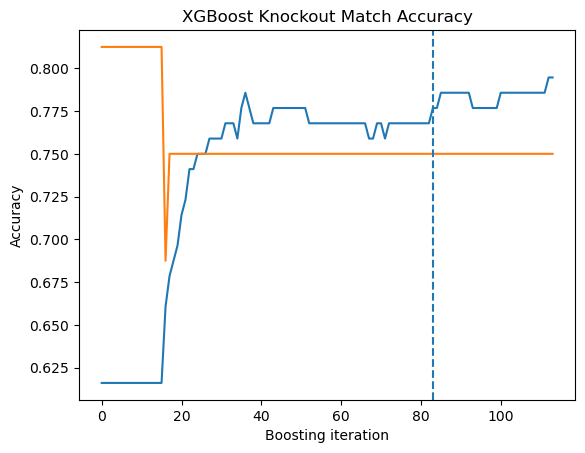

In [28]:
# Extract the accuracy recorded after each boosting iteration
evaluation_results = knockout_xgb_model.evals_result()

training_accuracy = (1 - np.array(evaluation_results["validation_0"]["error"]))
validation_accuracy = (1 - np.array(evaluation_results["validation_1"]["error"]))
print("Final training accuracy:",accuracy_score(Y_train_knockout, Y_train_knockout_pred))
print("Final validation accuracy:", accuracy_score(Y_val_knockout, Y_val_knockout_pred))

# Plot training and validation accuracy
plt.plot(training_accuracy, label="Training accuracy",)
plt.plot(validation_accuracy, label="Validation accuracy")
plt.axvline(
    knockout_xgb_model.best_iteration,
    linestyle="--",
    label="Best iteration",
)
plt.xlabel("Boosting iteration")
plt.ylabel("Accuracy")
plt.title("XGBoost Knockout Match Accuracy")
plt.show()

## Random Forest Model

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [30]:
# Build a Random Forest pipeline.
# Random Forest cannot directly handle missing values, so median imputation
# is applied before fitting the model.

rf_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=8,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the Random Forest using World Cup matches before 2022
rf_model.fit(X_train, Y_train)

# Generate predictions
Y_train_pred_rf = rf_model.predict(X_train)
Y_val_pred_rf = rf_model.predict(X_val)

# Calculate accuracy
rf_train_accuracy = accuracy_score(Y_train, Y_train_pred_rf)
rf_val_accuracy = accuracy_score(Y_val, Y_val_pred_rf)

print("Random Forest training accuracy:", round(rf_train_accuracy, 4))
print("Random Forest validation accuracy:", round(rf_val_accuracy, 4))

Random Forest training accuracy: 0.867
Random Forest validation accuracy: 0.4844


## Compare Random Forest and XGBoost

In [31]:
# Generate XGBoost training predictions
Y_train_pred_xgb = xgb_model.predict(X_train)

# Calculate XGBoost accuracy
xgb_train_accuracy = accuracy_score(Y_train, Y_train_pred_xgb)
xgb_val_accuracy = accuracy_score(Y_val, Y_val_pred)

# Create a comparison table
model_comparison = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest"],
    "Training Accuracy": [
        xgb_train_accuracy,
        rf_train_accuracy
    ],
    "Validation Accuracy": [
        xgb_val_accuracy,
        rf_val_accuracy
    ]
})

# Measure the training-validation gap
model_comparison["Generalization Gap"] = (
    model_comparison["Training Accuracy"]
    - model_comparison["Validation Accuracy"]
)

display(
    model_comparison.style.format({
        "Training Accuracy": "{:.4f}",
        "Validation Accuracy": "{:.4f}",
        "Generalization Gap": "{:.4f}"
    })
)

,Model,Training Accuracy,Validation Accuracy,Generalization Gap
0,XGBoost,0.6330,0.5312,0.1018
1,Random Forest,0.8670,0.4844,0.3826


### Plot the model comparison

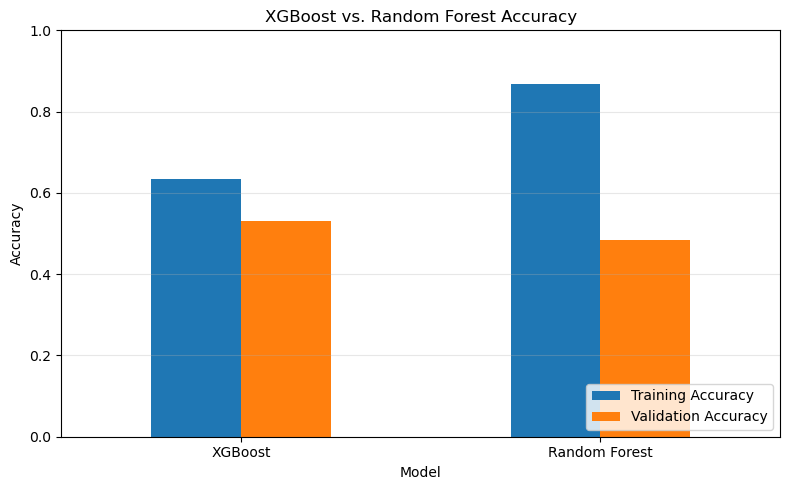

In [32]:
# Plot training and validation accuracy for both models
comparison_plot = model_comparison.set_index("Model")[
    ["Training Accuracy", "Validation Accuracy"]
]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(8, 5),
    ylim=(0, 1)
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("XGBoost vs. Random Forest Accuracy")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Print classification reports

In [33]:
class_names = [
    "First-listed team win",
    "Second-listed team win",
    "Draw"
]

print("XGBoost Classification Report")
print(
    classification_report(
        Y_val,
        Y_val_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

print("\nRandom Forest Classification Report")
print(
    classification_report(
        Y_val,
        Y_val_pred_rf,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

XGBoost Classification Report
                        precision    recall  f1-score   support

 First-listed team win     0.5349    0.7419    0.6216        31
Second-listed team win     0.5238    0.4783    0.5000        23
                  Draw     0.0000    0.0000    0.0000        10

              accuracy                         0.5312        64
             macro avg     0.3529    0.4067    0.3739        64
          weighted avg     0.4473    0.5312    0.4808        64


Random Forest Classification Report
                        precision    recall  f1-score   support

 First-listed team win     0.5758    0.6129    0.5938        31
Second-listed team win     0.4545    0.4348    0.4444        23
                  Draw     0.2222    0.2000    0.2105        10

              accuracy                         0.4844        64
             macro avg     0.4175    0.4159    0.4162        64
          weighted avg     0.4770    0.4844    0.4802        64



### Compare confusion matrices

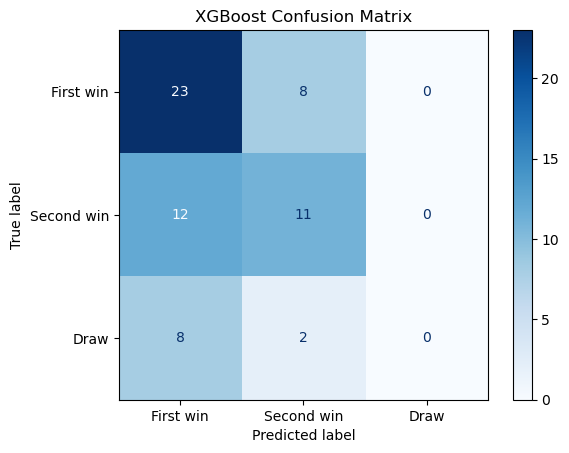

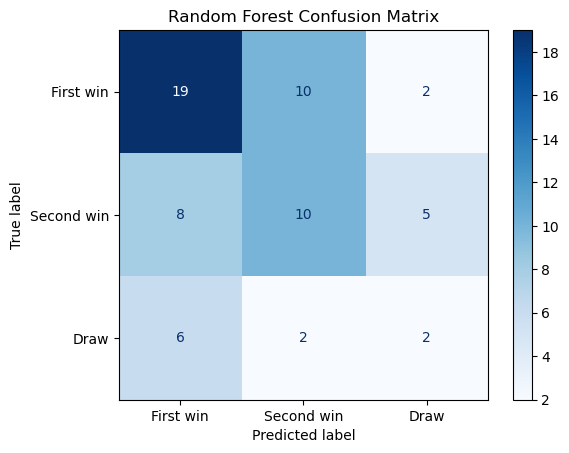

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    Y_val,
    Y_val_pred,
    display_labels=["First win", "Second win", "Draw"],
    cmap="Blues"
)
plt.title("XGBoost Confusion Matrix")
plt.show()

ConfusionMatrixDisplay.from_predictions(
    Y_val,
    Y_val_pred_rf,
    display_labels=["First win", "Second win", "Draw"],
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.show()

### Compare feature importance

,Feature,Random Forest Importance
2,elo_diff,0.225230
1,away_elo,0.199859
4,goal_difference_last_5_diff,0.181207
0,home_elo,0.165164
3,points_last_5_diff,0.123502
5,knockout_stage,0.105038


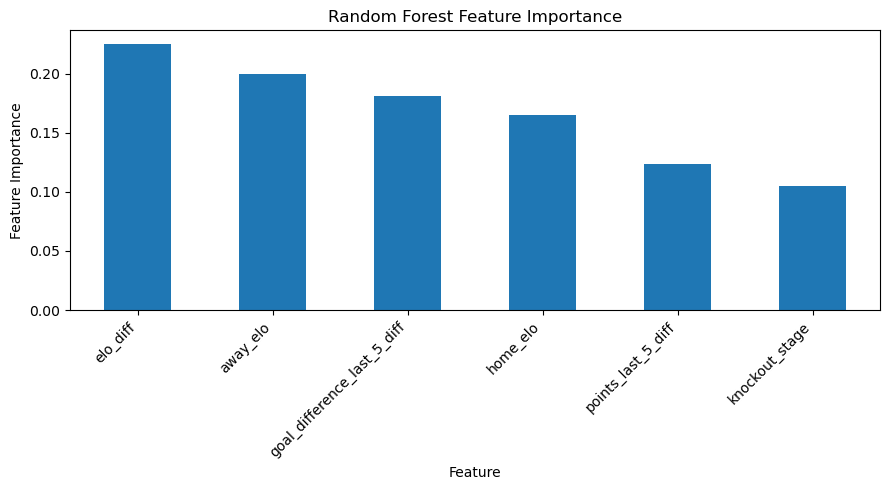

In [36]:
# Extract the fitted Random Forest classifier from the pipeline
fitted_rf_classifier = rf_model.named_steps["classifier"]

rf_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Random Forest Importance": fitted_rf_classifier.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    "Random Forest Importance",
    ascending=False
)

display(rf_feature_importance)

# Plot Random Forest feature importance
rf_feature_importance.set_index("Feature").plot(
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.ylabel("Feature Importance")
plt.xlabel("Feature")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,Feature,XGBoost Importance,Random Forest Importance
5,knockout_stage,0.284940,0.105038
2,elo_diff,0.198364,0.225230
4,goal_difference_last_5_diff,0.184851,0.181207
1,away_elo,0.125602,0.199859
0,home_elo,0.103635,0.165164
3,points_last_5_diff,0.102608,0.123502


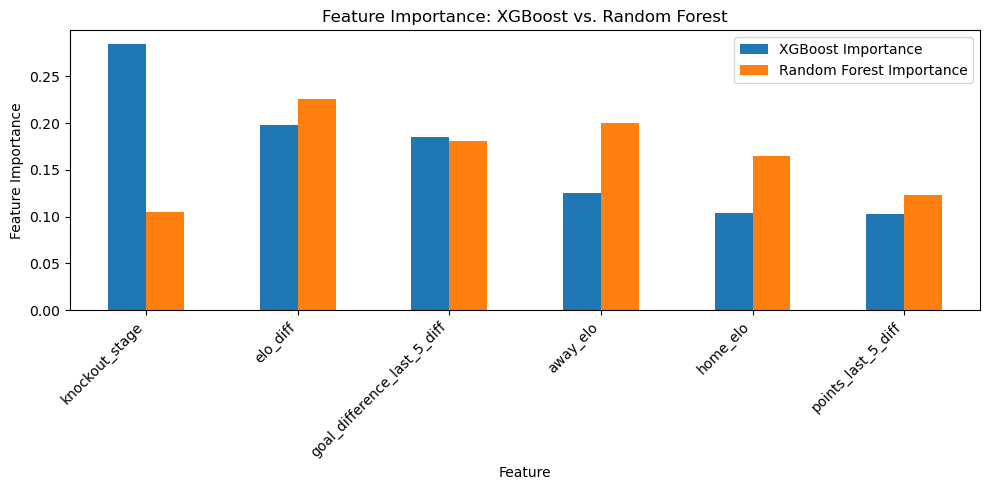

In [37]:
# XGBoost feature importance
xgb_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "XGBoost Importance": xgb_model.feature_importances_
})

# Random Forest feature importance
rf_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Random Forest Importance": fitted_rf_classifier.feature_importances_
})

feature_importance_comparison = (
    xgb_feature_importance
    .merge(rf_feature_importance, on="Feature")
    .sort_values("XGBoost Importance", ascending=False)
)

display(feature_importance_comparison)

feature_importance_comparison.set_index("Feature").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Feature Importance")
plt.xlabel("Feature")
plt.title("Feature Importance: XGBoost vs. Random Forest")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Random Forest for knockout matches

In [38]:
# Build the knockout-match Random Forest model
knockout_rf_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=6,
                min_samples_split=5,
                min_samples_leaf=2,
                max_features="sqrt",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
knockout_rf_model.fit(
    X_train_knockout,
    Y_train_knockout
)

# Predictions
Y_train_knockout_pred_rf = knockout_rf_model.predict(
    X_train_knockout
)

Y_val_knockout_pred_rf = knockout_rf_model.predict(
    X_val_knockout
)

# Accuracy
knockout_rf_train_accuracy = accuracy_score(
    Y_train_knockout,
    Y_train_knockout_pred_rf
)

knockout_rf_val_accuracy = accuracy_score(
    Y_val_knockout,
    Y_val_knockout_pred_rf
)

print(
    "Random Forest knockout training accuracy:",
    round(knockout_rf_train_accuracy, 4)
)

print(
    "Random Forest 2022 knockout validation accuracy:",
    round(knockout_rf_val_accuracy, 4)
)

Random Forest knockout training accuracy: 0.9286
Random Forest 2022 knockout validation accuracy: 0.75


### Comparing the two knockout models:

In [39]:
knockout_xgb_train_accuracy = accuracy_score(
    Y_train_knockout,
    Y_train_knockout_pred
)

knockout_xgb_val_accuracy = accuracy_score(
    Y_val_knockout,
    Y_val_knockout_pred
)

knockout_comparison = pd.DataFrame({
    "Model": [
        "XGBoost",
        "Random Forest"
    ],
    "Training Accuracy": [
        knockout_xgb_train_accuracy,
        knockout_rf_train_accuracy
    ],
    "Validation Accuracy": [
        knockout_xgb_val_accuracy,
        knockout_rf_val_accuracy
    ]
})

knockout_comparison["Generalization Gap"] = (
    knockout_comparison["Training Accuracy"]
    - knockout_comparison["Validation Accuracy"]
)

display(
    knockout_comparison.style.format({
        "Training Accuracy": "{:.4f}",
        "Validation Accuracy": "{:.4f}",
        "Generalization Gap": "{:.4f}"
    })
)

,Model,Training Accuracy,Validation Accuracy,Generalization Gap
0,XGBoost,0.7768,0.7500,0.0268
1,Random Forest,0.9286,0.7500,0.1786


### Plotting the knockout comparison

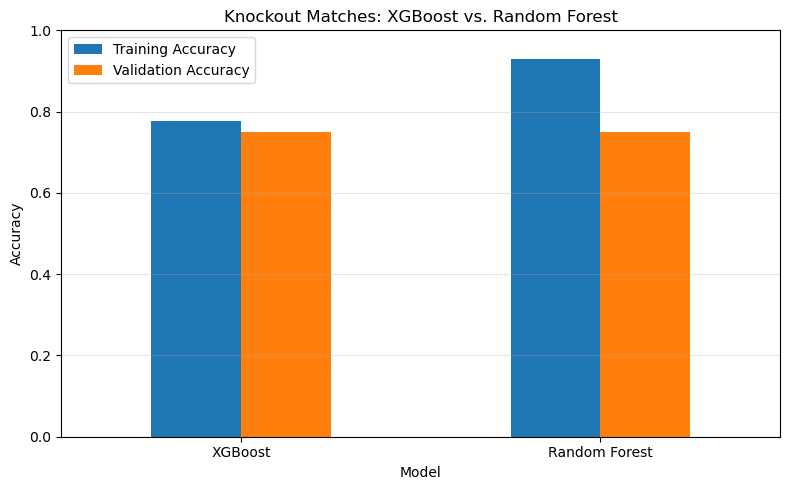

In [40]:
knockout_comparison.set_index("Model")[
    ["Training Accuracy", "Validation Accuracy"]
].plot(
    kind="bar",
    figsize=(8, 5),
    ylim=(0, 1)
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Knockout Matches: XGBoost vs. Random Forest")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Observations
- XGBoost achieved the highest validation accuracy (53.1%) on the overall World Cup prediction task.

- Random Forest achieved much higher training accuracy (86.7%) but lower validation accuracy (48.4%), indicating that it fit the training data more closely but generalized less effectively.

- For knockout-stage matches, both models achieved the same validation accuracy of 75%, although Random Forest attained a much higher training accuracy.

One of the most important observations is the difference between training and validation accuracy.

- XGBoost
    - Training accuracy ≈ 77.7%
    - Validation accuracy = 75% (knockout) / 53.1% (overall)
    - Small performance gap
    - Better generalization

- Random Forest
    - Training accuracy = 86.7%
    - Validation accuracy = 48.4%
    - Much larger performance gap
    - Stronger indication of overfitting

***XGBoost generalizes better to unseen matches, while Random Forest memorizes the training data more aggressively.***

- XGBoost
    - Better overall accuracy
    
    - Strongest performance predicting first-listed team wins
    
    - Reasonable precision and recall for second-listed team wins
    
    - Did not successfully predict draws

    - Overall Accuracy: 53.1%

- Random Forest
    - Lower overall accuracy
    - Slightly better at identifying draws
    - Lower precision and recall for the two winning classes

    - Overall Accuracy:48.4%

***Feature Importance***

Both models identified similar important predictors.

XGBoost

Most important features:

Knockout Stage
Elo Difference
Goal Difference (Last 5 Matches)
Away Elo
Home Elo
Points Difference (Last 5)

XGBoost relied heavily on whether a match was a knockout game.

Random Forest

Most important features:

Elo Difference
Away Elo
Goal Difference (Last 5 Matches)
Home Elo
Points Difference (Last 5)
Knockout Stage

Random Forest relied more heavily on team strength (Elo ratings) than on the match stage.

Based on the experimental results:

XGBoost is the preferred model for predicting FIFA World Cup match outcomes in comparision to RandomForest because it achieved higher validation accuracy (53.1% vs. 48.4%) and demonstrated better generalization to unseen data.
Although Random Forest achieved higher training accuracy, the larger gap between training and validation performance indicates greater overfitting.
For knockout-stage matches, both models performed equally well (75% validation accuracy), but XGBoost reached this performance with less evidence of overfitting.

Overall, XGBoost provides the better balance between predictive accuracy and generalization, making it the recommended model for the final World Cup prediction system.